Key Questions
1. **Profitability** — Which product categories generate the most profit, and how much of that comes from sales volume versus per-unit margin?

2. **Returns & discounting** — Does heavier discounting correlate with higher return rates, and how much profit (if any) do returns actually cost each category?

In [26]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
sns.set_theme(style="whitegrid")

In [28]:
connection = sql.connect('../retail_data/retail_store.db')

In [29]:
##Question 1
##Which product categories generate the most profit, 
##and how much of that comes from sales volume versus per-unit margin?

categories_vs_sales_vs_per_unit_margin = pd.read_sql_query("""
SELECT cat.CategoryName, 
    SUM(od.Quantity * (od.UnitPrice * (1 - od.DiscountRate) - od.UnitCost)) AS TotalProfit, -- finding total profit for each category
    SUM(od.Quantity) AS TotalSalesVolume, -- total sales volume for each category
    SUM(od.Quantity * (od.UnitPrice * (1 - od.DiscountRate) - od.UnitCost)) / SUM(od.Quantity) AS WeightedPerUnitMargin -- weighted per-unit margin for each category
FROM categories AS cat
INNER JOIN products AS p
    ON cat.CategoryID = p.CategoryID
INNER JOIN order_details AS od
    ON p.ProductID = od.ProductID
GROUP BY cat.CategoryName
ORDER BY TotalProfit DESC;
"""
, connection)

categories_vs_sales_vs_per_unit_margin.info() ## checking if there's any null values

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CategoryName           10 non-null     str    
 1   TotalProfit            10 non-null     float64
 2   TotalSalesVolume       10 non-null     int64  
 3   WeightedPerUnitMargin  10 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 452.0 bytes


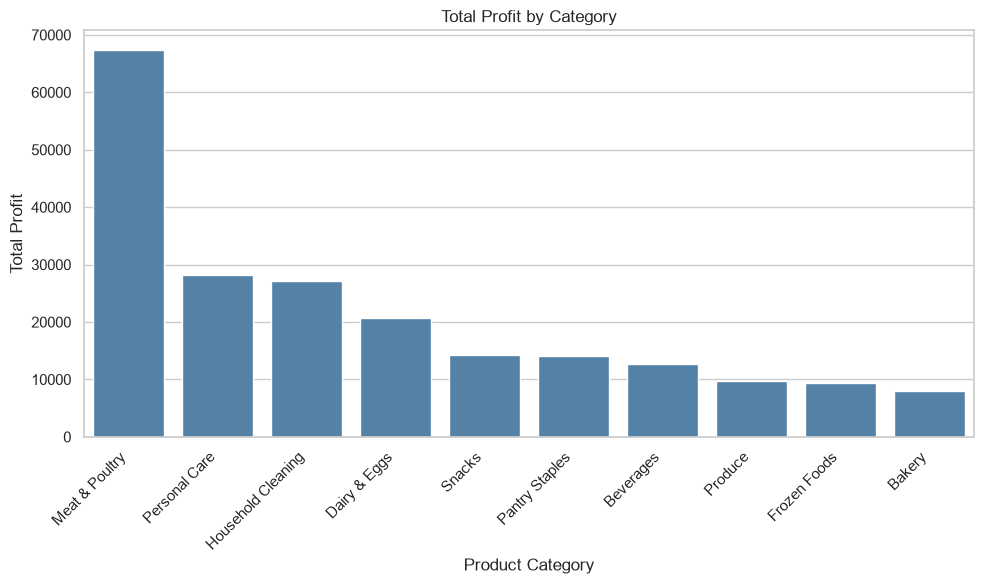

In [ ]:
##Visualization
##Which category genrates the most profit?
category_plot = categories_vs_sales_vs_per_unit_margin.sort_values('TotalProfit', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=category_plot,
    x='CategoryName',
    y='TotalProfit',
    color='steelblue'
)
plt.xlabel('Product Category')
plt.ylabel('Total Profit')
plt.title('Total Profit by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

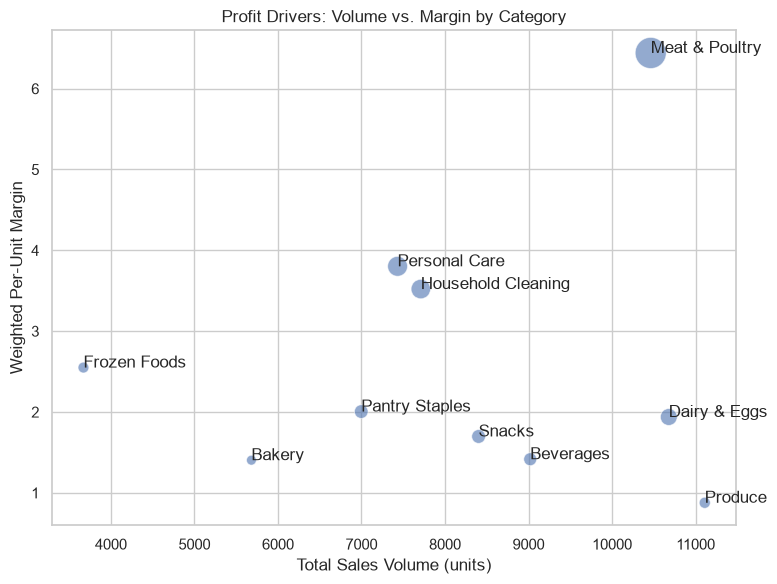

In [ ]:
##Visualization
##Volume vs Per-Unit Margin
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=category_plot,
    x='TotalSalesVolume',
    y='WeightedPerUnitMargin',
    size='TotalProfit',
    sizes=(50, 500),
    alpha=0.6,
    legend=False,
)

for _, row in category_plot.iterrows():
    ax.annotate(row['CategoryName'], (row['TotalSalesVolume'], row['WeightedPerUnitMargin']))
ax.set_xlabel('Total Sales Volume (units)')
ax.set_ylabel('Weighted Per-Unit Margin')
ax.set_title('Profit Drivers: Volume vs. Margin by Category')
plt.tight_layout()
plt.show()

## Interpretation

Profitable?

It depends on the category. There is no direct answer that states that one category is better than another.

The Meat & Poultry category generated the highest profit by category having Personal Care and Hoosehold Cleaning below it. The lowest category generating profit are bakery and frozen foods. The gap between the Meat & Poultry" among the other category is particularly noticable. 

Why is the Meat & Poultry so profitable? Meat & Poultry products simply have a high price point (steaks, salmon), so even a modest percentage markup produces a large dollar amount per unit. Its profit dominance is a volume + price-point story, not a pricing-efficiency story — it isn't the best-run category in terms of markup, it just moves a lot of relatively expensive product. Take note that the WeightedPerUnitMargin is a dollar figure, not a percentage —  Meat & Poultry's high dollar margin does not means high markup, we know from the earlier SQL exploration its percentage margin is actually the lowest.


Household Cleaning and Personal Care shows a different pattern. They top the percentage-margin chart and rank 2nd-3rd in dollar margin per unit, despite only middling sales volume (~7,400-7,700 units, well below Meat & Poultry's ~10,500). Their profit is a margin-efficiency story — they earn less per category overall mainly because they don't sell as much, not because they're priced poorly.

The general pattern that was found: perishable products (Meat & Poultry, Dairy & Eggs, Produce) tend to have high volume with low percentage margins, while non-perishable items (Household Cleaning, Personal Care) has to have low volume with high percentage margin.

